Data Preprocessing

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets

# metadata
print(wholesale_customers.metadata)

# variable information
print(wholesale_customers.variables)


{'uci_id': 292, 'name': 'Wholesale customers', 'repository_url': 'https://archive.ics.uci.edu/dataset/292/wholesale+customers', 'data_url': 'https://archive.ics.uci.edu/static/public/292/data.csv', 'abstract': 'The data set refers to clients of a wholesale distributor. It includes the annual spending in monetary units (m.u.) on diverse product categories', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 440, 'num_features': 7, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Region'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5030X', 'creators': ['Margarida Cardoso'], 'intro_paper': None, 'additional_info': {'summary': None, 'purpose': None, 'funded_by': None, 'instances_represent': None, 'recommended_data_splits': None, 'sensitive_data': None, 'preprocessing_description':

In [3]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [4]:
#building data frame
df = pd.concat([y, X], axis=1)

spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

print(f"Shape: {df.shape}")
df.head()

Shape: (440, 8)


,Region,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,3,2,12669,9656,7561,214,2674,1338
1,3,2,7057,9810,9568,1762,3293,1776
2,3,2,6353,8808,7684,2405,3516,7844
3,3,1,13265,1196,4221,6404,507,1788
4,3,2,22615,5410,7198,3915,1777,5185


In [5]:
#inspecting structure
print("="*55)
print(f"  Samples : {df.shape[0]}")
print(f"  Features: {df.shape[1]}")
print("="*55)

print("\n Data Types")
print(df.dtypes)

print("\n Stat")
display(df.describe())

  Samples : 440
  Features: 8

 Data Types
Region              int64
Channel             int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

 Stat


,Region,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,2.543182,1.322727,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.774272,0.468052,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,2.000000,1.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,3.000000,1.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,3.000000,2.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,3.000000,2.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
#check for any missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

if missing.sum() == 0:
    print("\n no missing values ")
else:
    print("\n missing values , add median instead ")
    df.fillna(df.median(numeric_only=True), inplace=True)

Missing values per column:
Region              0
Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

 no missing values 


In [7]:
# checking for duplicates and removing them
n_before = len(df)
df.drop_duplicates(inplace=True)
n_after = len(df)

print(f"Rows before       : {n_before}")
print(f"Rows after        : {n_after}")
print(f"Duplicates removed: {n_before - n_after}")


Rows before       : 440
Rows after        : 440
Duplicates removed: 0


In [8]:
# resplit el x wel y after el concat el kan fel awl
df.reset_index(drop=True, inplace=True)
X = df[spending_cols].copy()
y = df[['Channel', 'Region']].copy()

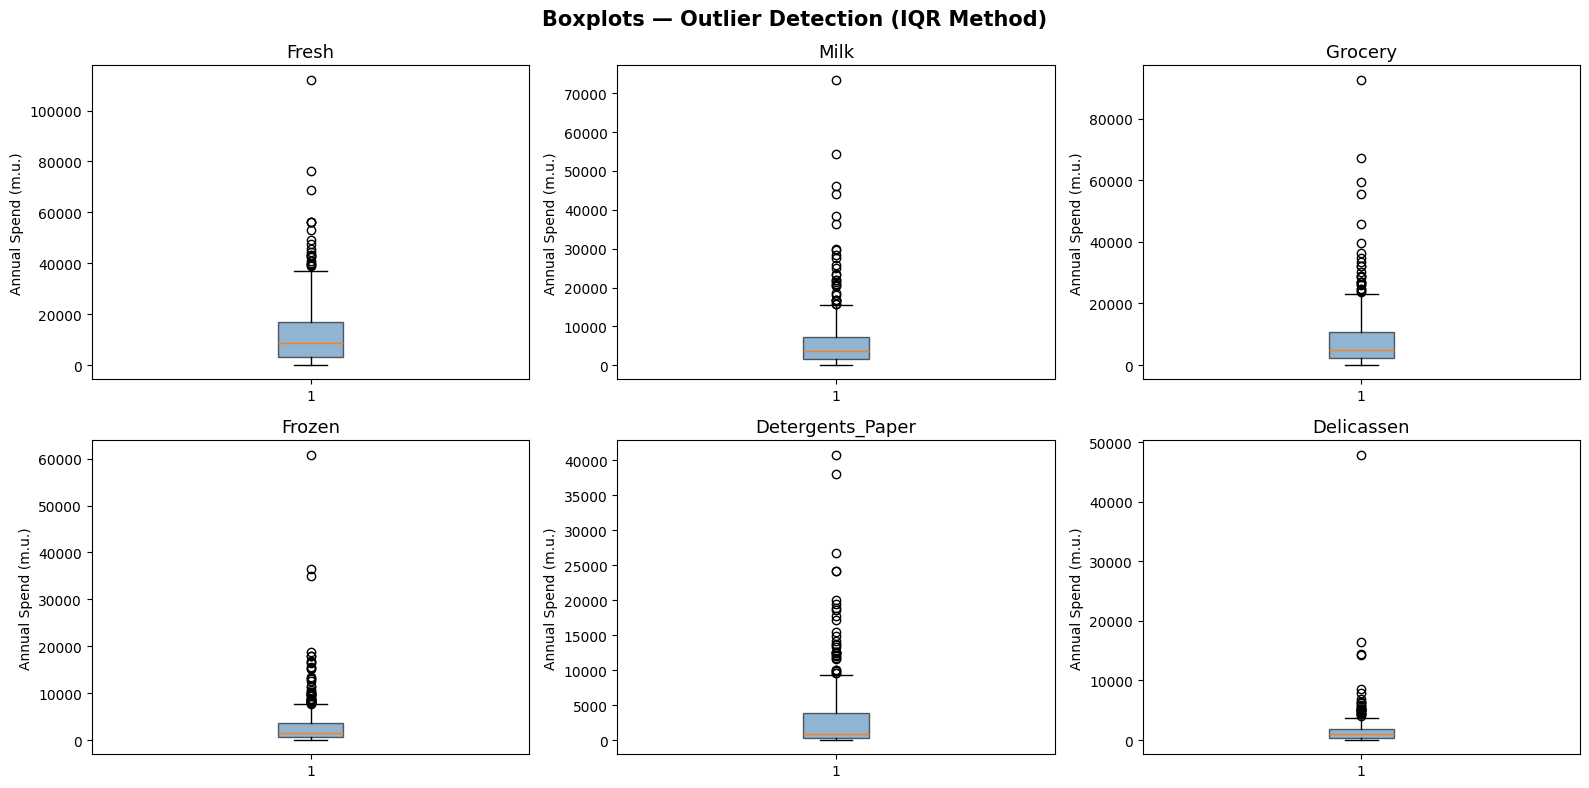

In [9]:
# checking for outliers before normalization
#1- boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    axes[i].boxplot(X[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=13)
    axes[i].set_ylabel('Annual Spend (m.u.)')

plt.suptitle('Boxplots — Outlier Detection (IQR Method)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
#2- z score
print("\n Z-Score outlier count (|z| > 3) per feature")
z_scores = np.abs(stats.zscore(X))
outlier_counts = (z_scores > 3).sum()
print(outlier_counts)


 Z-Score outlier count (|z| > 3) per feature
43


outliers are detected but they represent high volume customers so we will not remove them  however standardization will reduce their influence

we will use standardization and not min max because all features are right skewed and min max hykhaly values (0,1)  , standard scaler will be better and robust

In [11]:
#standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=spending_cols)

print(f"\nMean per feature (should be 0):\n{X_scaled_df.mean().round(6)}")
print(f"\nStd  per feature (should be 1):\n{X_scaled_df.std().round(6)}")


Mean per feature (should be 0):
Fresh              -0.0
Milk                0.0
Grocery            -0.0
Frozen              0.0
Detergents_Paper    0.0
Delicassen         -0.0
dtype: float64

Std  per feature (should be 1):
Fresh               1.001138
Milk                1.001138
Grocery             1.001138
Frozen              1.001138
Detergents_Paper    1.001138
Delicassen          1.001138
dtype: float64


we don't need pca as we already have 6 features only , we don't need dimensionality reduction  , this will affect the clustering process however we can use it for visualization only

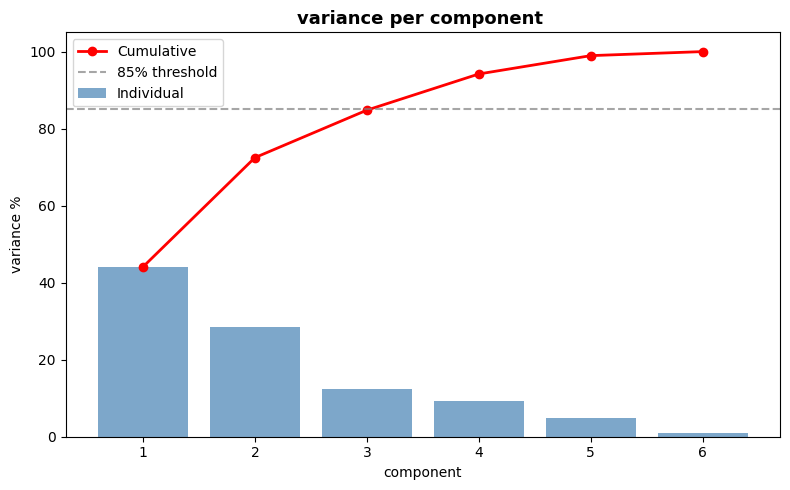


  Variance per Component 
PC1: 44.08%  |  Cumulative: 44.08%
PC2: 28.38%  |  Cumulative: 72.46%
PC3: 12.33%  |  Cumulative: 84.79%
PC4: 9.40%  |  Cumulative: 94.19%
PC5: 4.76%  |  Cumulative: 98.95%
PC6: 1.05%  |  Cumulative: 100.00%
Variance captured by PC1 + PC2: 72.46%


In [12]:
#PCA FOR VISUALIZATION WITHOUT REDUCTION
pca_full = PCA()
pca_full.fit(X_scaled)

explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot explained variance
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, 7), explained * 100, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, 7), cumulative * 100, 'ro-', linewidth=2, label='Cumulative')
ax.axhline(85, color='gray', linestyle='--', alpha=0.7, label='85% threshold')
ax.set_xlabel('component')
ax.set_ylabel('variance %')
ax.set_title('variance per component ', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\n  Variance per Component ")
for i, (ind, cum) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {ind*100:.2f}%  |  Cumulative: {cum*100:.2f}%")

# Fit 2D PCA — used in visualization cells
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)
print(f"Variance captured by PC1 + PC2: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")


Data visualization

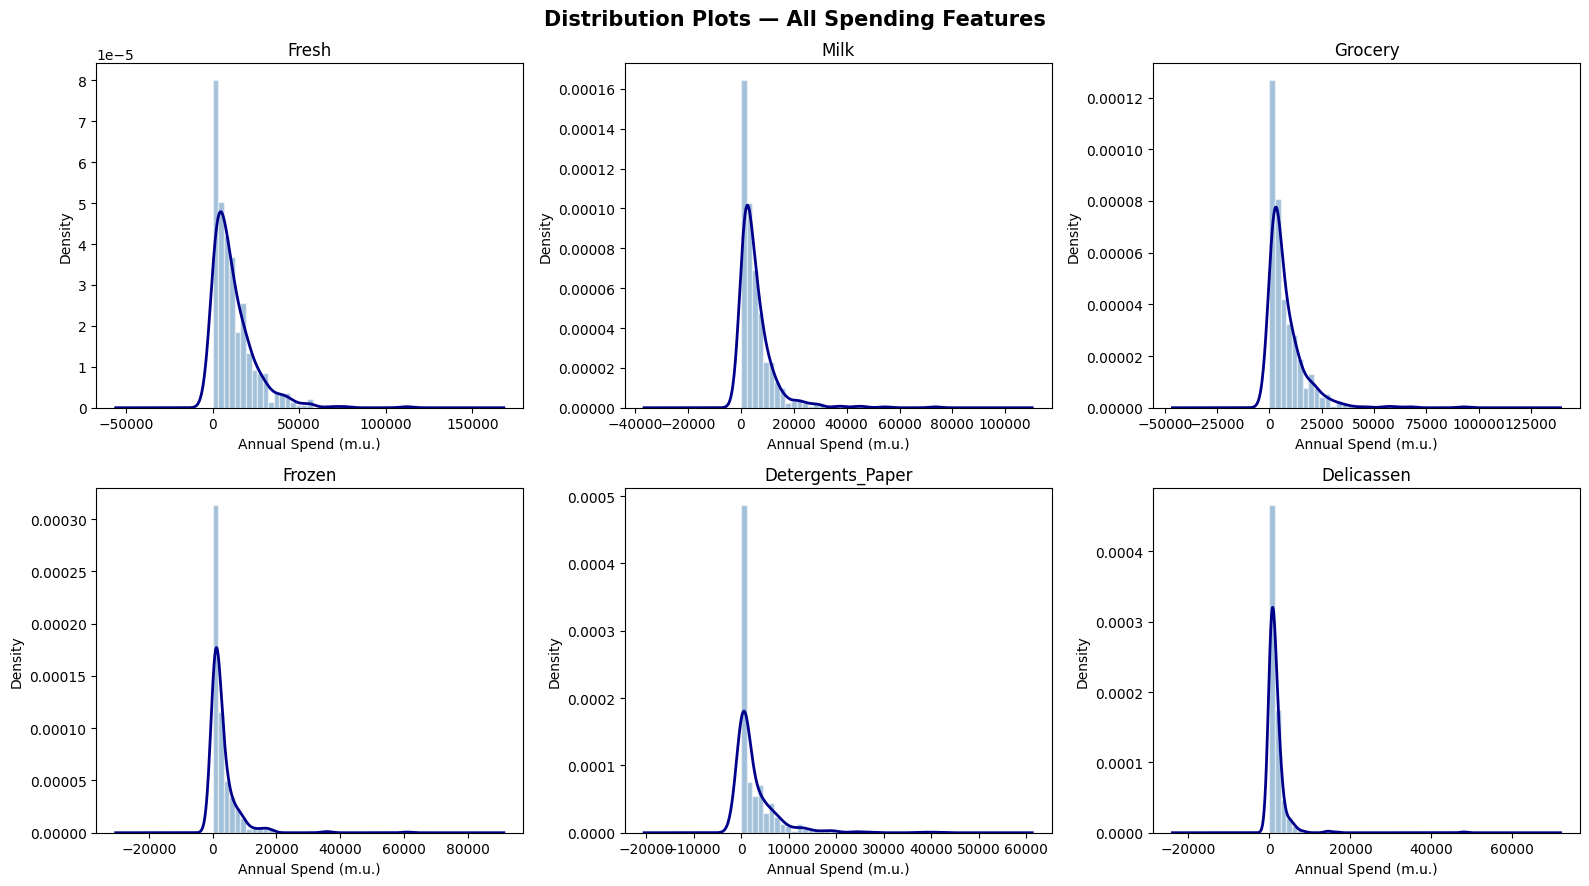

In [13]:
#• Distribution plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    axes[i].hist(X[col], bins=35, color='steelblue', alpha=0.5,
                 density=True, edgecolor='white')
    X[col].plot.kde(ax=axes[i], color='darkblue', linewidth=2)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Annual Spend (m.u.)')
    axes[i].set_ylabel('Density')

plt.suptitle('Distribution Plots — All Spending Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

interpretation : all features are right skewed

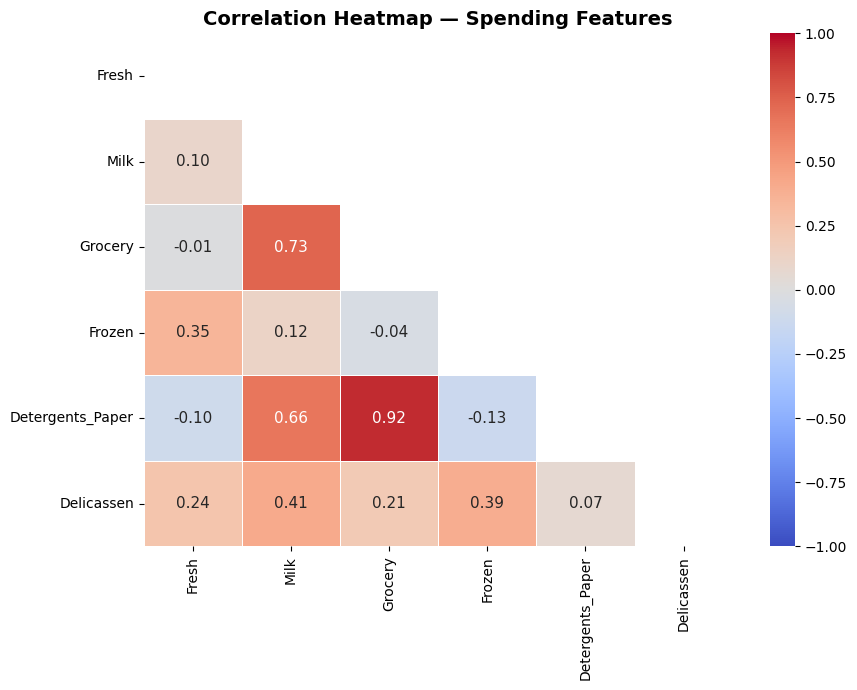

In [14]:
#• Correlation heatmap to analyze relationships between variables
corr = X.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 11})
ax.set_title('Correlation Heatmap — Spending Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

interpretation : grocery and detergent are positively correlated  , also milk has moderate correlation to them  while fresh and frozen are independent of others

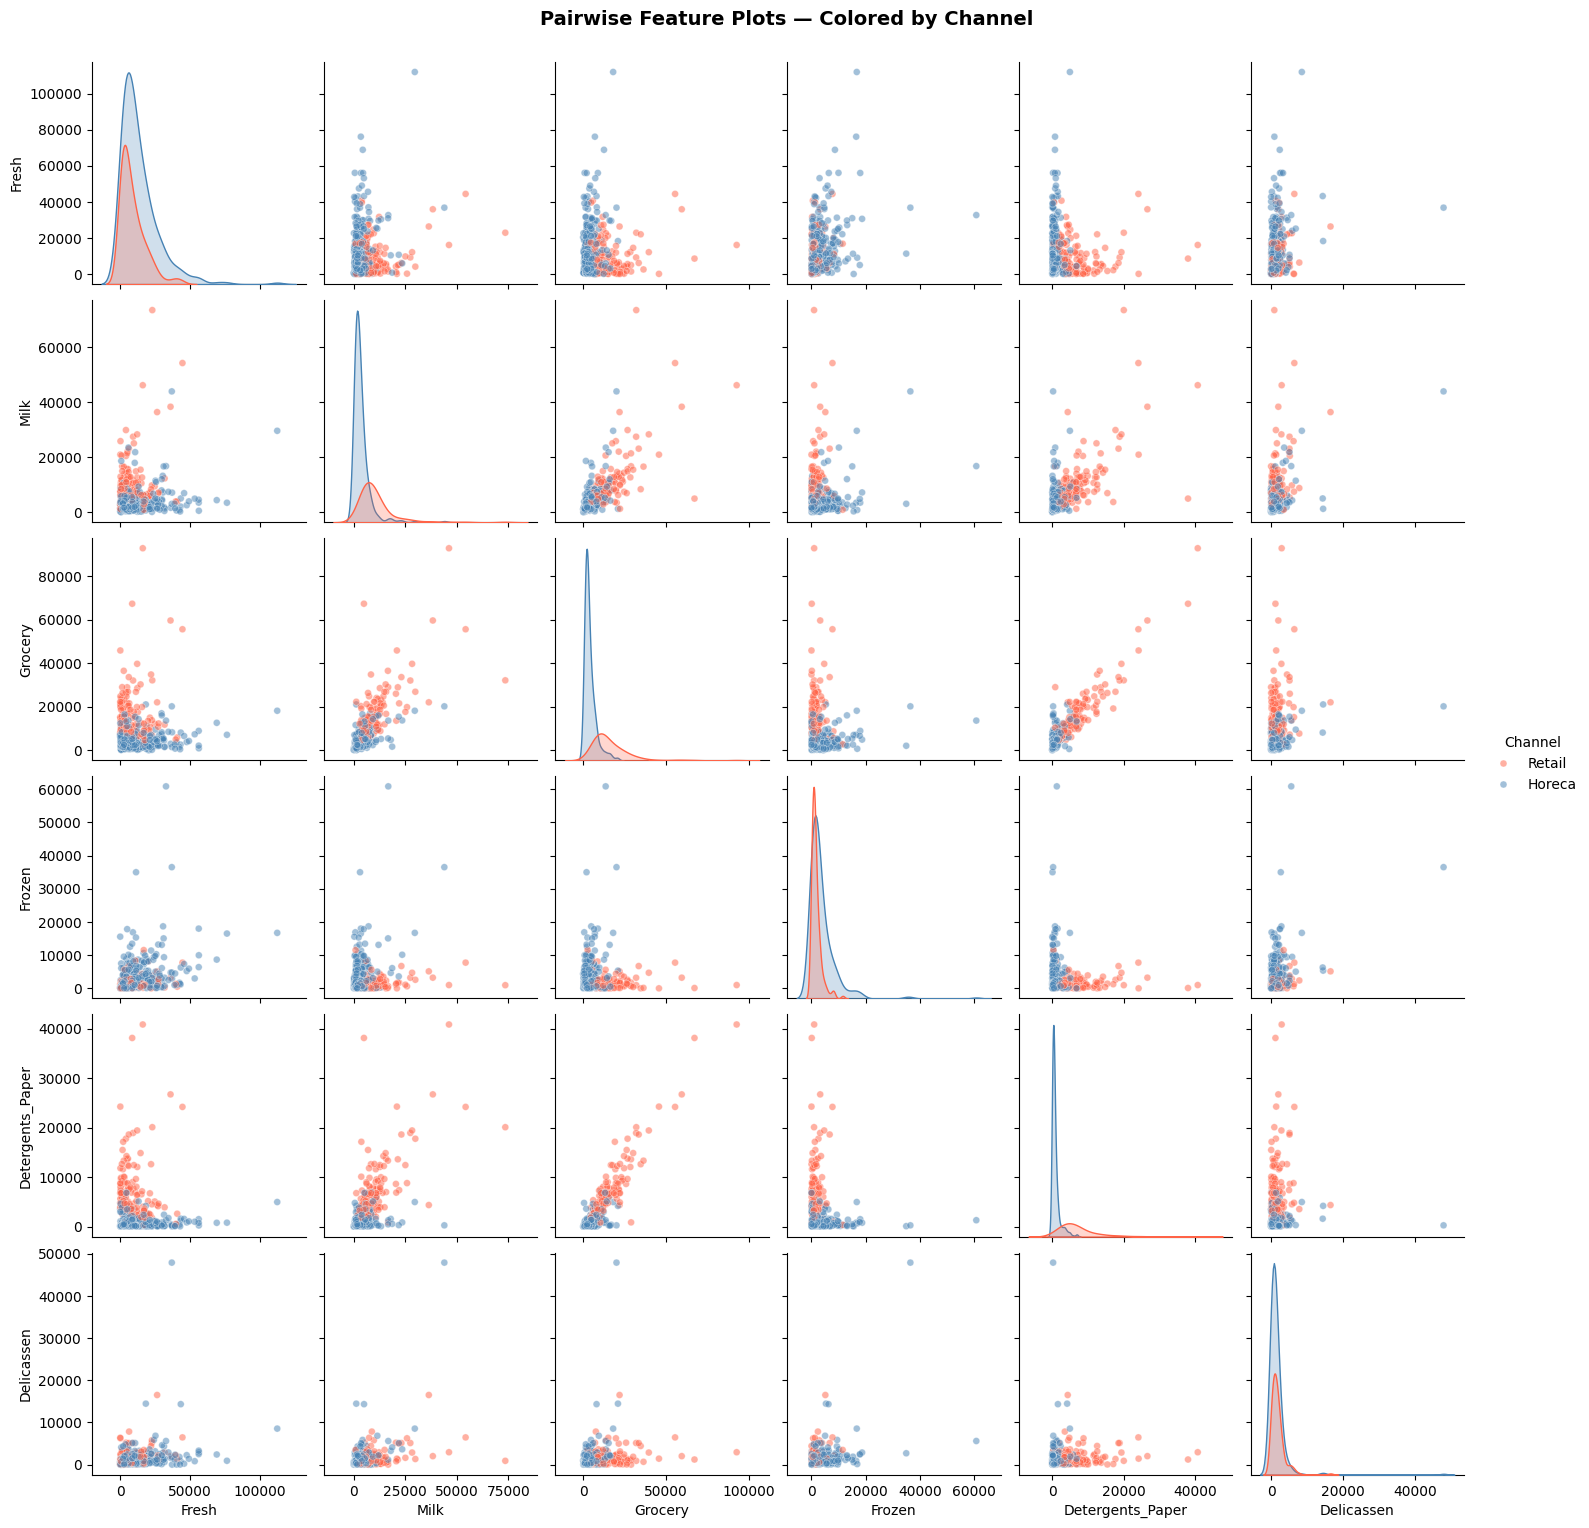

In [15]:
#• Pairwise feature plots to observe feature interactions.
pair_df = X.copy()
pair_df['Channel'] = y['Channel'].map({1: 'Horeca', 2: 'Retail'}).values

g = sns.pairplot(pair_df, hue='Channel', diag_kind='kde',
                 plot_kws=dict(alpha=0.5, s=25),
                 palette={'Horeca': 'steelblue', 'Retail': 'tomato'})
g.fig.suptitle('Pairwise Feature Plots — Colored by Channel',
               y=1.02, fontsize=14, fontweight='bold')
plt.show()

interpretation :grocery vs detergents pair shows the clearest
separation between Horeca and Retail channels

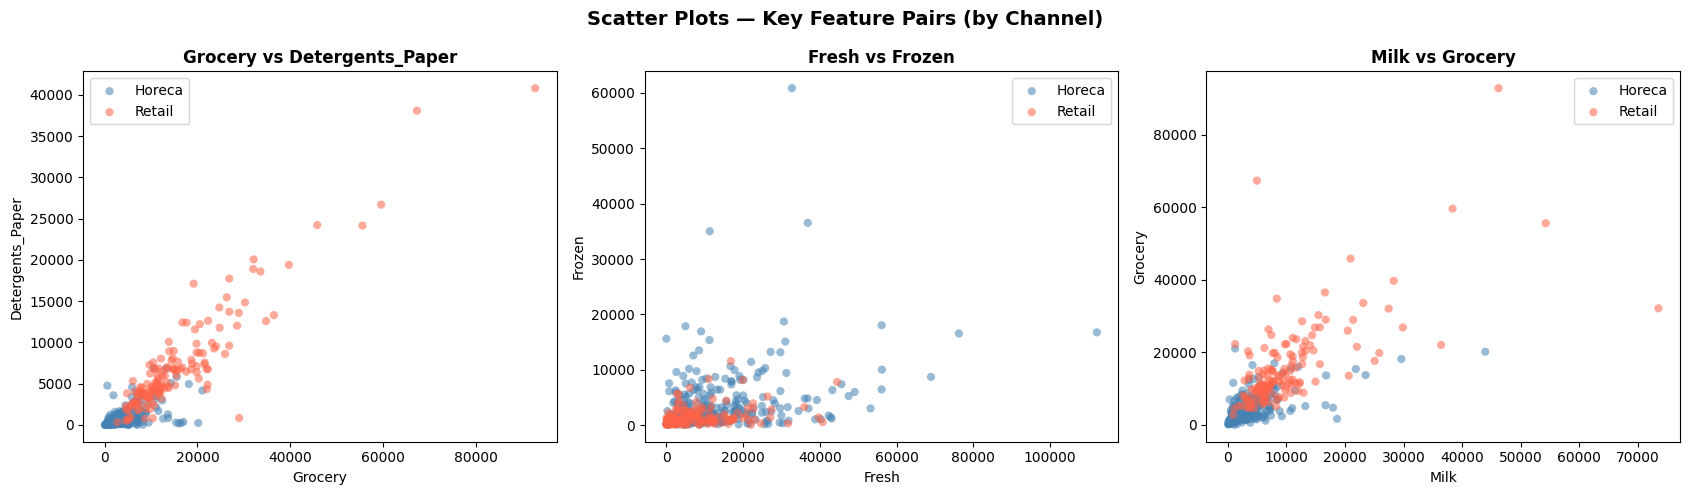

In [16]:
#• Scatter plots between selected feature pairs.
key_pairs = [
    ('Grocery', 'Detergents_Paper'),
    ('Fresh',   'Frozen'),
    ('Milk',    'Grocery'),
]

palette = {'Horeca': 'steelblue', 'Retail': 'tomato'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (fx, fy) in zip(axes, key_pairs):
    for ch, label in [(1, 'Horeca'), (2, 'Retail')]:
        mask = (y['Channel'] == ch).values
        ax.scatter(X.loc[mask, fx], X.loc[mask, fy],
                   c=palette[label], label=label,
                   alpha=0.55, s=35, edgecolors='none')
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}', fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Scatter Plots — Key Feature Pairs (by Channel)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


interpratation :  

1- Grocery vs Detergents: clearest separation (Retail customers) , cluster is in upper right : high spendings on both

2-Fresh vs Frozen: both channels overlap more, but horeca customers
tend to spend more on Fresh produce.

3-Milk vs Grocery: moderate separation — Retail customers again skew : spendings are higher in both


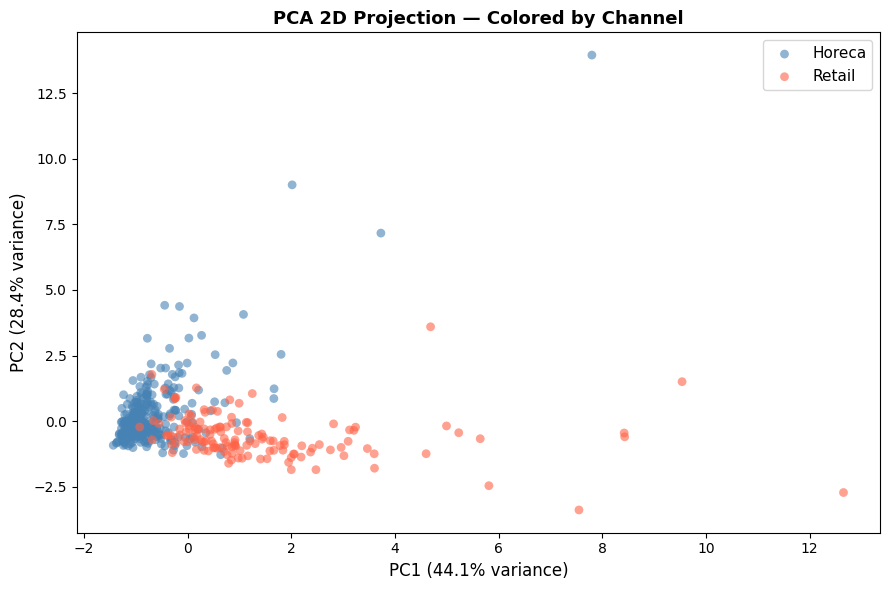

In [17]:
#• Two-dimensional visualization using PCA projection
palette = {'Horeca': 'steelblue', 'Retail': 'tomato'}

fig, ax = plt.subplots(figsize=(9, 6))
for ch, label in [(1, 'Horeca'), (2, 'Retail')]:
    mask = y['Channel'].values == ch
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=palette[label], label=label,
               alpha=0.6, s=40, edgecolors='none')

var1, var2 = pca_2d.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=12)
ax.set_title('PCA 2D Projection — Colored by Channel',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

interpretation :  imperfect separation between Horeca and Retail customers, with some
overlap in the middle , in data they maybe not perfectly linearly separable

c:\Users\My Lap\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


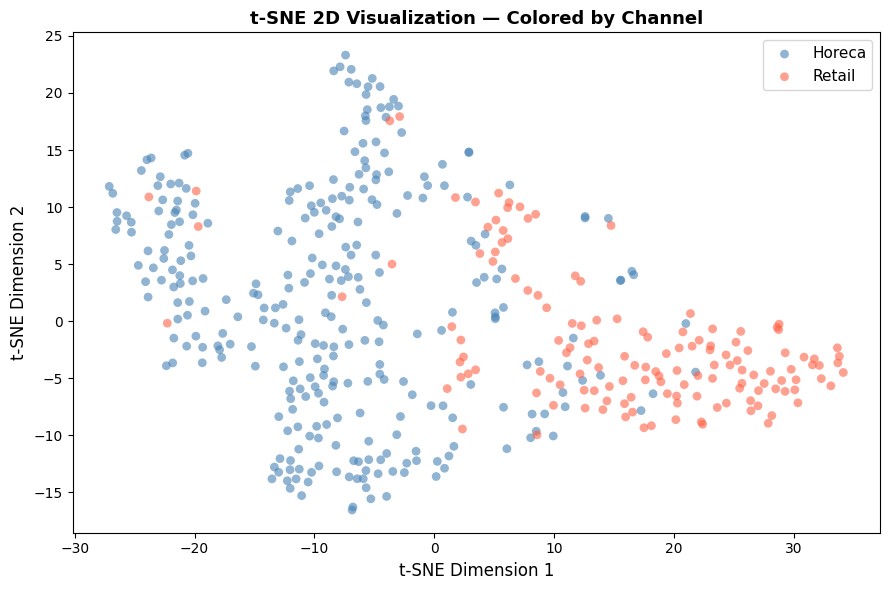

In [18]:
#• Apply t-SNE to obtain a non-linear two-dimensional visualization of the dataset.
#If it’s not necessary to use any of the above, write your explanation.
tsne = TSNE(n_components=2, perplexity=30, random_state=42,
            learning_rate='auto', init='pca', n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

palette = {'Horeca': 'steelblue', 'Retail': 'tomato'}

fig, ax = plt.subplots(figsize=(9, 6))
for ch, label in [(1, 'Horeca'), (2, 'Retail')]:
    mask = y['Channel'].values == ch
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=palette[label], label=label,
               alpha=0.6, s=40, edgecolors='none')

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('t-SNE 2D Visualization — Colored by Channel',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

why did we use t-SNE?
because PCA is a linear method and our data is not linearly separable data so PCA will not reveal cluster structure however t-SNE maps high dimnsional data

interpretation : we have more compact separation between horeca and retail customers , also sub clusters are visible which means that all clustering techniques requested in the milestone EXCEPT FOR ELBOW may find more than 2 groups in data

In [19]:
# data prep for clustering after scaling
df_export = X_scaled_df.copy()
df_export['Channel'] = y['Channel'].values
df_export['Region']  = y['Region'].values

df_export.to_csv('wholesale_scaled.csv', index=False)

print(" wholesale_scaled.csv saved.")
print(f"   Shape: {df_export.shape}")
print("""
Variables ready for the clustering team:
  X_scaled     → numpy array (440, 6) — feed directly to K-Means, GMM, Spectral
  X_scaled_df  → same as DataFrame
  X_pca2       → numpy array (440, 2) — for 2D cluster visualization
  X_tsne       → numpy array (440, 2) — for 2D cluster visualization
  y['Channel'] → ground-truth labels  — for post-clustering evaluation only
""")

 wholesale_scaled.csv saved.
   Shape: (440, 8)

Variables ready for the clustering team:
  X_scaled     → numpy array (440, 6) — feed directly to K-Means, GMM, Spectral
  X_scaled_df  → same as DataFrame
  X_pca2       → numpy array (440, 2) — for 2D cluster visualization
  X_tsne       → numpy array (440, 2) — for 2D cluster visualization
  y['Channel'] → ground-truth labels  — for post-clustering evaluation only

